# Clasificación Multiclase con PyTorch — One vs All
### Dataset: Fashion Product Images (styles.csv + images/)
**Laboratorio:** Inteligencia Artificial I  
**Objetivo:** Clasificar imágenes de productos de moda en sus categorías principales  
usando una Red Neuronal en PyTorch con Dataset, DataLoader y Checkpoints,  
basado en el modelo One-vs-All implementado en laboratorios anteriores.

---
## Contenido
1. Importaciones y configuración
2. Carga y balanceo del dataset (styles.csv)
3. Preprocesamiento de imágenes con OpenCV
4. Codificación de clases y división 80/20
5. Visualización de imágenes del dataset
6. Clase Dataset personalizada + DataLoader
7. Red Neuronal para clasificación multiclase
8. Entrenamiento con gráficas de costo y precisión + checkpoints
9. Evaluación del modelo
10. Guardar y cargar el modelo
11. Predicción sobre una imagen nueva


## 1. Importaciones y Configuración

In [13]:
# ─── Librerías principales ───────────────────────────────────────────────────
import torch                              # Framework principal de Deep Learning
import torch.nn as nn                     # Módulo para construir redes neuronales
import numpy as np                        # Operaciones matemáticas con arrays
import pandas as pd                       # Carga y manipulación del CSV de estilos
import os                                 # Manejo de rutas y directorios
import cv2                                # Procesamiento de imágenes (redimensionar, normalizar)
import matplotlib.pyplot as plt           # Visualización de imágenes y gráficas
from PIL import Image                     # Para abrir imágenes en formato .webp y otros

# ─── Scikit-learn: preprocesamiento y métricas ────────────────────────────────
from sklearn.model_selection import train_test_split   # División 80/20
from sklearn.preprocessing import LabelEncoder         # Codificar nombres de clases a números
from sklearn.metrics import (
    accuracy_score,        # porcentaje de aciertos total
    confusion_matrix,      # tabla de aciertos y errores por clase
    classification_report  # precisión, recall y F1 por clase
)

# ─── Configuración del dispositivo ───────────────────────────────────────────
# Si hay GPU disponible la usamos — el procesamiento de imágenes se beneficia mucho de esto
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo disponible: {device}")

Dispositivo disponible: cpu


## 2. Carga y Balanceo del Dataset
Leemos `styles.csv` que contiene los metadatos de cada producto.  
**El balanceo es obligatorio** según la consigna para evitar que el modelo  
aprenda mejor las clases con más ejemplos y ignore las minoritarias.

In [14]:
# ─── Carga del CSV de estilos ─────────────────────────────────────────────────
df = pd.read_csv('styles.csv', on_bad_lines='skip')
df = df[['id', 'masterCategory']].dropna()

print(f"Total de registros: {len(df):,}")
print()
print("Distribución ANTES del balanceo:")
print(df['masterCategory'].value_counts())

Total de registros: 44,424

Distribución ANTES del balanceo:
masterCategory
Apparel           21397
Accessories       11274
Footwear           9219
Personal Care      2403
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64


In [15]:
# ─── Balanceo: eliminamos clases con muy pocos ejemplos ──────────────────────
MIN_EJEMPLOS = 500
conteo = df['masterCategory'].value_counts()
clases_validas = conteo[conteo >= MIN_EJEMPLOS].index
df = df[df['masterCategory'].isin(clases_validas)].copy()

print(f"Clases válidas: {list(clases_validas)}")

# Balanceo compatible con pandas nuevos
min_samples = df['masterCategory'].value_counts().min()
print(f"Muestras por clase: {min_samples:,}")

# Tomamos min_samples de cada clase por separado y concatenamos
partes = []
for clase in clases_validas:
    subset = df[df['masterCategory'] == clase].sample(n=min_samples, random_state=42)
    partes.append(subset)

df_balanced = pd.concat(partes).reset_index(drop=True)

print(f"Total registros balanceados: {len(df_balanced):,}")
print()
print("Distribución DESPUÉS del balanceo:")
print(df_balanced['masterCategory'].value_counts())

Clases válidas: ['Apparel', 'Accessories', 'Footwear', 'Personal Care']
Muestras por clase: 2,403
Total registros balanceados: 9,612

Distribución DESPUÉS del balanceo:
masterCategory
Apparel          2403
Accessories      2403
Footwear         2403
Personal Care    2403
Name: count, dtype: int64


## 3. Preprocesamiento de Imágenes con OpenCV
Cargamos cada imagen usando su `id`, la redimensionamos a **32x32 píxeles**  
y la aplanamos en un vector de **3072 valores** (32 × 32 × 3 canales RGB).  
Esto convierte cada imagen en un vector de características para la red neuronal.

In [16]:
# ─── Carga y preprocesamiento de imágenes ────────────────────────────────────
# Ajustá la ruta a la carpeta donde tenés las imágenes
IMAGE_DIR = 'images'

images = []    # lista de vectores de imagen aplanados
labels = []    # lista de etiquetas (masterCategory)
ids_cargados = []

print("Cargando imágenes...")

for _, row in df_balanced.iterrows():
    # Construimos la ruta completa del archivo
    path = os.path.join(IMAGE_DIR, str(row['id']) + '.jpg')

    if os.path.exists(path):
        # Leemos la imagen con OpenCV (devuelve array BGR)
        img = cv2.imread(path)

        if img is not None:
            # ── Redimensionar a 32x32 píxeles ─────────────────────────────
            # Todas las imágenes deben tener el mismo tamaño para la red
            img = cv2.resize(img, (32, 32))

            # ── Convertir BGR → RGB ────────────────────────────────────────
            # OpenCV lee en BGR, pero mostramos en RGB (matplotlib usa RGB)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # ── Normalizar: valores de 0-255 → 0.0-1.0 ────────────────────
            # Igual que en el lab anterior. Escala uniforme mejora el entrenamiento
            img = img / 255.0

            # ── Aplanar: (32, 32, 3) → vector de 3072 valores ─────────────
            # La red neuronal espera un vector 1D, no una matriz 3D
            img = img.flatten()

            images.append(img)
            labels.append(row['masterCategory'])
            ids_cargados.append(row['id'])

# Convertir listas a arrays numpy
X = np.array(images, dtype=np.float32)
y_raw = np.array(labels)

print(f"\nImágenes cargadas correctamente: {len(X):,}")
print(f"Shape de X: {X.shape}")   # (n_imagenes, 3072)
print(f"Shape de y: {y_raw.shape}")

Cargando imágenes...

Imágenes cargadas correctamente: 9,612
Shape de X: (9612, 3072)
Shape de y: (9612,)


## 4. Codificación de Clases y División 80/20
Convertimos los nombres de categorías (texto) a números con `LabelEncoder`,  
luego dividimos en 80% entrenamiento y 20% prueba.

In [17]:
# ─── Codificación de etiquetas de texto a números ─────────────────────────────
# LabelEncoder asigna un número único a cada categoría:
# Ej: 'Apparel' → 0, 'Accessories' → 1, 'Footwear' → 2, etc.
# Esto es necesario porque la red trabaja con números, no con texto

le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Clases y su código numérico:")
for i, clase in enumerate(le.classes_):
    count = np.sum(y == i)
    print(f"  {i}: {clase:<20} → {count:,} imágenes")

NUM_CLASES = len(le.classes_)
print(f"\nNúmero total de clases: {NUM_CLASES}")

Clases y su código numérico:
  0: Accessories          → 2,403 imágenes
  1: Apparel              → 2,403 imágenes
  2: Footwear             → 2,403 imágenes
  3: Personal Care        → 2,403 imágenes

Número total de clases: 4


In [18]:
# ─── División 80% entrenamiento / 20% prueba ─────────────────────────────────
# Las imágenes de prueba NO participan en el entrenamiento (consigna del lab)
# stratify=y garantiza que cada split tenga la misma proporción de clases

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% para prueba
    random_state=42,     # semilla para reproducibilidad
    stratify=y           # mantener proporción de clases
)

print(f"Entrenamiento: {X_train.shape[0]:,} imágenes ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Prueba:        {X_test.shape[0]:,} imágenes ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Shape de cada imagen aplanada: {X_train.shape[1]} valores (32×32×3)")

Entrenamiento: 7,689 imágenes (80%)
Prueba:        1,923 imágenes (20%)
Shape de cada imagen aplanada: 3072 valores (32×32×3)


## 5. Visualización de Imágenes del Dataset
Mostramos ejemplos aleatorios del conjunto de entrenamiento para verificar que la carga fue correcta.

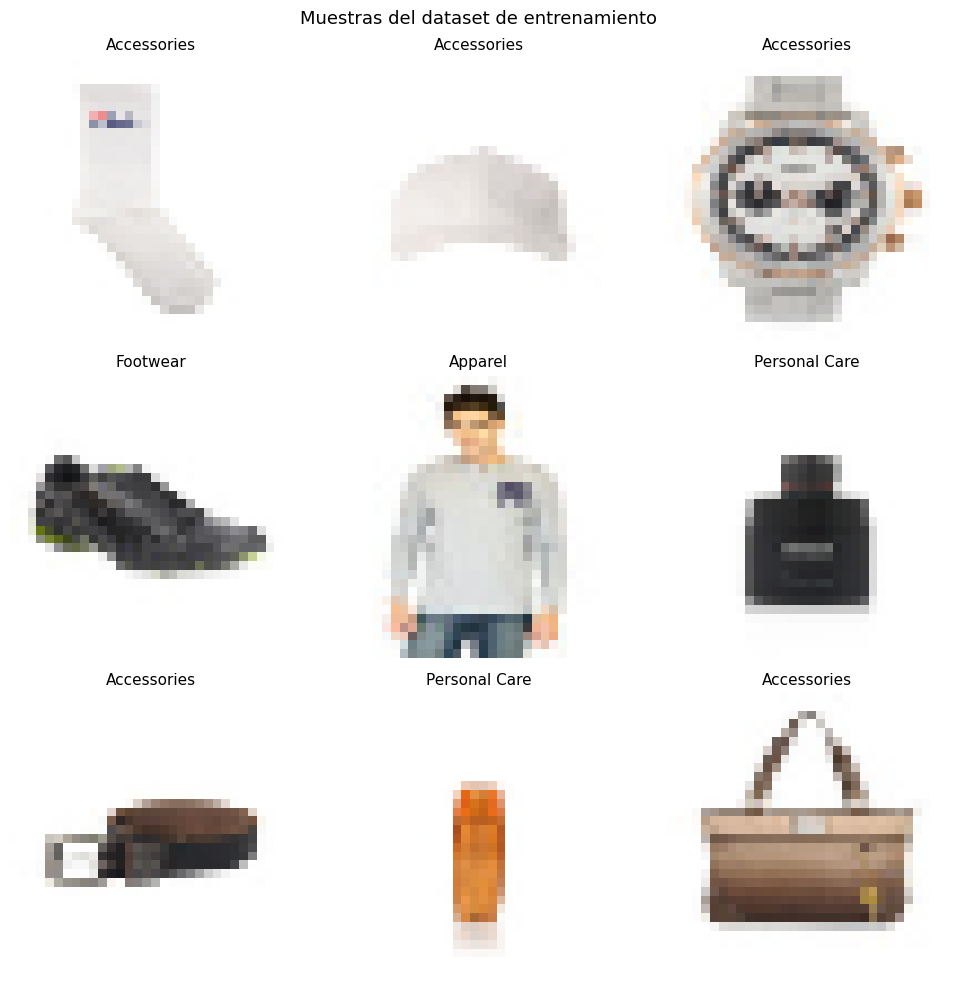

In [19]:
# ─── Mostrar imágenes de muestra ─────────────────────────────────────────────
# Visualizamos 9 imágenes aleatorias del conjunto de entrenamiento
# Las imágenes están aplanadas (3072 valores), las reconstruimos a (32, 32, 3)

def mostrar_imagenes(X, y, le, n=9):
    """
    Muestra n imágenes aleatorias del conjunto con su etiqueta predicha
    X: array de imágenes aplanadas
    y: array de etiquetas numéricas
    le: LabelEncoder para convertir número → nombre de clase
    """
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    indices = np.random.choice(len(X), n, replace=False)

    for i, idx in enumerate(indices):
        ax = axes[i // 3][i % 3]
        # Reconstruir imagen: vector 3072 → (32, 32, 3)
        img = X[idx].reshape(32, 32, 3)
        ax.imshow(img)
        # Mostrar el nombre de la clase
        ax.set_title(le.inverse_transform([y[idx]])[0], fontsize=11)
        ax.axis('off')

    plt.suptitle('Muestras del dataset de entrenamiento', fontsize=13)
    plt.tight_layout()
    plt.show()

mostrar_imagenes(X_train, y_train, le)

## 6. Clase Dataset Personalizada + DataLoader
Aplicamos el patrón del cuadernillo 03: creamos `FashionDataset`  
para manejar las imágenes y usamos `DataLoader` para mini-batches.

In [20]:
# ─── Clase Dataset para imágenes de moda ─────────────────────────────────────
class FashionDataset(torch.utils.data.Dataset):

    def __init__(self, X, y):
        """
        Constructor: convierte arrays numpy a tensores de PyTorch
        X: matriz de imágenes aplanadas (n_imagenes, 3072) → float32
        y: vector de etiquetas numéricas                   → long (enteros para CrossEntropy)
        """
        # float32 para las imágenes (valores entre 0.0 y 1.0)
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        # long (int64) para las etiquetas — requerido por CrossEntropyLoss
        self.y = torch.tensor(y, dtype=torch.long).to(device)

    def __len__(self):
        """Retorna la cantidad total de imágenes en el dataset"""
        return len(self.X)

    def __getitem__(self, idx):
        """Retorna la imagen y etiqueta en la posición idx"""
        return self.X[idx], self.y[idx]


# ─── Instanciar datasets ──────────────────────────────────────────────────────
dataset_train = FashionDataset(X_train, y_train)
dataset_test  = FashionDataset(X_test,  y_test)

print(f"Dataset entrenamiento: {len(dataset_train):,} imágenes")
print(f"Dataset prueba:        {len(dataset_test):,} imágenes")

# Verificamos forma de una muestra
img_muestra, label_muestra = dataset_train[0]
print(f"\nShape de una imagen (tensor): {img_muestra.shape}")  # (3072,)
print(f"Etiqueta: {label_muestra.item()} → {le.classes_[label_muestra.item()]}")

Dataset entrenamiento: 7,689 imágenes
Dataset prueba:        1,923 imágenes

Shape de una imagen (tensor): torch.Size([3072])
Etiqueta: 0 → Accessories


In [21]:
# ─── DataLoader: gestiona la iteración en mini-batches ───────────────────────
# batch_size=64: procesa 64 imágenes a la vez
# shuffle=True en train: mezcla el orden en cada época → mejor generalización

BATCH_SIZE = 64

dataloader_train = torch.utils.data.DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True    # mezclar imágenes en cada época
)

dataloader_test = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=BATCH_SIZE,
    shuffle=False   # no mezclar para evaluación
)

# Verificamos el shape de un batch
img_batch, label_batch = next(iter(dataloader_train))
print(f"Shape de un batch de imágenes: {img_batch.shape}")   # (64, 3072)
print(f"Shape de un batch de etiquetas: {label_batch.shape}") # (64,)

Shape de un batch de imágenes: torch.Size([64, 3072])
Shape de un batch de etiquetas: torch.Size([64])


## 7. Red Neuronal para Clasificación Multiclase
En el lab anterior usamos **One-vs-All**: entrenamos un clasificador binario por clase.  
Ahora reemplazamos eso por una red neuronal que aprende todas las clases a la vez,  
usando `Softmax` implícito en `CrossEntropyLoss` como capa de salida.

In [22]:
# ─── Red Neuronal para clasificación multiclase (imágenes) ──────────────────
class RedMulticlase(nn.Module):

    def __init__(self, n_entradas, n_ocultas_1=512, n_ocultas_2=256, n_ocultas_3=128, n_clases=7):
        """
        n_entradas:   tamaño del vector de imagen aplanada (32*32*3 = 3072)
        n_ocultas_1/2/3: neuronas en cada capa oculta
        n_clases:     número de categorías de moda a clasificar
        """
        super(RedMulticlase, self).__init__()

        # ── Capas de la red ──────────────────────────────────────────────────
        # Capa 1: 3072 entradas → 512 neuronas
        self.capa1 = nn.Linear(n_entradas, n_ocultas_1)
        # Capa 2: 512 → 256
        self.capa2 = nn.Linear(n_ocultas_1, n_ocultas_2)
        # Capa 3: 256 → 128
        self.capa3 = nn.Linear(n_ocultas_2, n_ocultas_3)
        # Salida: 128 → n_clases (una neurona por categoría)
        # NO aplicamos Softmax aquí porque CrossEntropyLoss lo incluye internamente
        self.salida = nn.Linear(n_ocultas_3, n_clases)

        # ── Activación ReLU ───────────────────────────────────────────────────
        # Introduce no linealidad: sin esto la red sería una regresión lineal
        self.relu = nn.ReLU()

        # ── Batch Normalization ───────────────────────────────────────────────
        # Normaliza las activaciones dentro de cada batch
        # Estabiliza el entrenamiento y permite usar learning rates más altos
        self.bn1 = nn.BatchNorm1d(n_ocultas_1)
        self.bn2 = nn.BatchNorm1d(n_ocultas_2)
        self.bn3 = nn.BatchNorm1d(n_ocultas_3)

        # ── Dropout ───────────────────────────────────────────────────────────
        # Apaga neuronas aleatoriamente durante el entrenamiento
        # Evita que la red memorice los datos (overfitting)
        self.dropout = nn.Dropout(p=0.4)

    def forward(self, x):
        """
        Propagación hacia adelante: define cómo fluyen los datos
        Equivalente a: h = sigmoid(X @ theta) del lab anterior (para cada clase)
        """
        # Capa 1: lineal → BatchNorm → ReLU → Dropout
        x = self.dropout(self.relu(self.bn1(self.capa1(x))))
        # Capa 2: lineal → BatchNorm → ReLU → Dropout
        x = self.dropout(self.relu(self.bn2(self.capa2(x))))
        # Capa 3: lineal → BatchNorm → ReLU → Dropout
        x = self.dropout(self.relu(self.bn3(self.capa3(x))))
        # Capa de salida: produce un score por cada clase (logits)
        # CrossEntropyLoss aplica Softmax internamente
        x = self.salida(x)
        return x


# ─── Instanciar modelo ────────────────────────────────────────────────────────
N_ENTRADAS = X_train.shape[1]   # 3072 (32*32*3)
modelo = RedMulticlase(n_entradas=N_ENTRADAS, n_clases=NUM_CLASES).to(device)

print(modelo)
print(f"\nNúmero de parámetros entrenables: {sum(p.numel() for p in modelo.parameters()):,}")

RedMulticlase(
  (capa1): Linear(in_features=3072, out_features=512, bias=True)
  (capa2): Linear(in_features=512, out_features=256, bias=True)
  (capa3): Linear(in_features=256, out_features=128, bias=True)
  (salida): Linear(in_features=128, out_features=4, bias=True)
  (relu): ReLU()
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.4, inplace=False)
)

Número de parámetros entrenables: 1,739,908


## 8. Entrenamiento con Gráficas de Costo y Precisión + Checkpoints
Usamos `CrossEntropyLoss` que es la generalización de `BCELoss` para múltiples clases.  
Internamente aplica Softmax y calcula la misma función J(θ) del lab anterior pero para K clases.

In [23]:
criterio = nn.CrossEntropyLoss()

optimizador = torch.optim.Adam(modelo.parameters(), lr=0.001, weight_decay=1e-4)

# Se quitó verbose=True porque ya no es compatible con PyTorch 2.6+
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador, mode='min', patience=5, factor=0.5
)

EPOCHS = 50
CHECKPOINT_PATH = './multiclase_mejor_modelo.pt'

print(f"Función de costo: CrossEntropyLoss")
print(f"Optimizador: Adam (lr=0.001)")
print(f"Épocas: {EPOCHS}")
print(f"Clases a clasificar: {list(le.classes_)}")

Función de costo: CrossEntropyLoss
Optimizador: Adam (lr=0.001)
Épocas: 50
Clases a clasificar: [np.str_('Accessories'), np.str_('Apparel'), np.str_('Footwear'), np.str_('Personal Care')]


In [24]:
# ─── Bucle de entrenamiento ───────────────────────────────────────────────────
historico_costo_train = []    # costo promedio por época (para la gráfica)
historico_costo_test  = []    # costo en validación por época
historico_acc_train   = []    # precisión en entrenamiento por época
historico_acc_test    = []    # precisión en validación por época
mejor_acc             = 0.0   # guardamos el modelo con mejor accuracy en test

for epoca in range(1, EPOCHS + 1):

    # ── FASE DE ENTRENAMIENTO ────────────────────────────────────────────────
    modelo.train()   # activa Dropout y BatchNorm en modo entrenamiento
    costos_train, preds_train, labels_train = [], [], []

    for img_batch, label_batch in dataloader_train:
        # 1. Forward: la red produce scores (logits) para cada clase
        logits = modelo(img_batch)

        # 2. Calculamos el costo (CrossEntropy incluye Softmax internamente)
        costo = criterio(logits, label_batch)
        costos_train.append(costo.item())

        # 3. Reseteamos los gradientes antes de calcular los nuevos
        optimizador.zero_grad()

        # 4. Backpropagation: calcula ∂J/∂θ para cada parámetro
        costo.backward()

        # 5. El optimizador actualiza los pesos (equivalente a θ = θ - α*gradiente)
        optimizador.step()

        # Guardamos predicciones (la clase con mayor score = argmax)
        preds_train.extend(torch.argmax(logits, dim=1).cpu().numpy())
        labels_train.extend(label_batch.cpu().numpy())

    # ── FASE DE VALIDACIÓN ───────────────────────────────────────────────────
    modelo.eval()    # desactiva Dropout, BatchNorm usa estadísticas globales
    costos_test, preds_test, labels_test = [], [], []

    with torch.no_grad():   # no calculamos gradientes al evaluar
        for img_batch, label_batch in dataloader_test:
            logits = modelo(img_batch)
            costo  = criterio(logits, label_batch)
            costos_test.append(costo.item())
            preds_test.extend(torch.argmax(logits, dim=1).cpu().numpy())
            labels_test.extend(label_batch.cpu().numpy())

    # ── Métricas de la época ─────────────────────────────────────────────────
    costo_tr = np.mean(costos_train)
    costo_te = np.mean(costos_test)
    acc_tr   = accuracy_score(labels_train, preds_train)
    acc_te   = accuracy_score(labels_test,  preds_test)

    historico_costo_train.append(costo_tr)
    historico_costo_test.append(costo_te)
    historico_acc_train.append(acc_tr)
    historico_acc_test.append(acc_te)

    scheduler.step(costo_te)

    # ── CHECKPOINT: guardar si es el mejor modelo ────────────────────────────
    if acc_te > mejor_acc:
        mejor_acc = acc_te
        torch.save(modelo.state_dict(), CHECKPOINT_PATH)
        print(f"  ✔ Época {epoca:2d} | Nuevo mejor modelo (val_acc={acc_te:.4f})")

    if not epoca % 5:
        print(f"  Época {epoca:2d}/{EPOCHS} | Train Loss: {costo_tr:.4f} Acc: {acc_tr:.4f} | Val Loss: {costo_te:.4f} Acc: {acc_te:.4f}")

# Cargamos el mejor modelo al finalizar
modelo.load_state_dict(torch.load(CHECKPOINT_PATH, weights_only=True))
print(f"\n✔ Entrenamiento finalizado. Mejor val_acc: {mejor_acc:.4f}")

  ✔ Época  1 | Nuevo mejor modelo (val_acc=0.7551)
  ✔ Época  3 | Nuevo mejor modelo (val_acc=0.7936)
  ✔ Época  4 | Nuevo mejor modelo (val_acc=0.9116)
  Época  5/50 | Train Loss: 0.1834 Acc: 0.9426 | Val Loss: 0.3636 Acc: 0.8612
  ✔ Época 10 | Nuevo mejor modelo (val_acc=0.9350)
  Época 10/50 | Train Loss: 0.1213 Acc: 0.9623 | Val Loss: 0.1944 Acc: 0.9350
  Época 15/50 | Train Loss: 0.1146 Acc: 0.9612 | Val Loss: 1.0652 Acc: 0.7431
  ✔ Época 18 | Nuevo mejor modelo (val_acc=0.9615)
  Época 20/50 | Train Loss: 0.0753 Acc: 0.9767 | Val Loss: 0.1374 Acc: 0.9490
  Época 25/50 | Train Loss: 0.0679 Acc: 0.9789 | Val Loss: 0.1738 Acc: 0.9381
  ✔ Época 27 | Nuevo mejor modelo (val_acc=0.9636)
  ✔ Época 28 | Nuevo mejor modelo (val_acc=0.9657)
  Época 30/50 | Train Loss: 0.0551 Acc: 0.9828 | Val Loss: 0.2079 Acc: 0.9345
  ✔ Época 31 | Nuevo mejor modelo (val_acc=0.9678)
  Época 35/50 | Train Loss: 0.0488 Acc: 0.9837 | Val Loss: 0.2247 Acc: 0.9288
  ✔ Época 39 | Nuevo mejor modelo (val_acc=0.9

## 9. Evaluación del Modelo

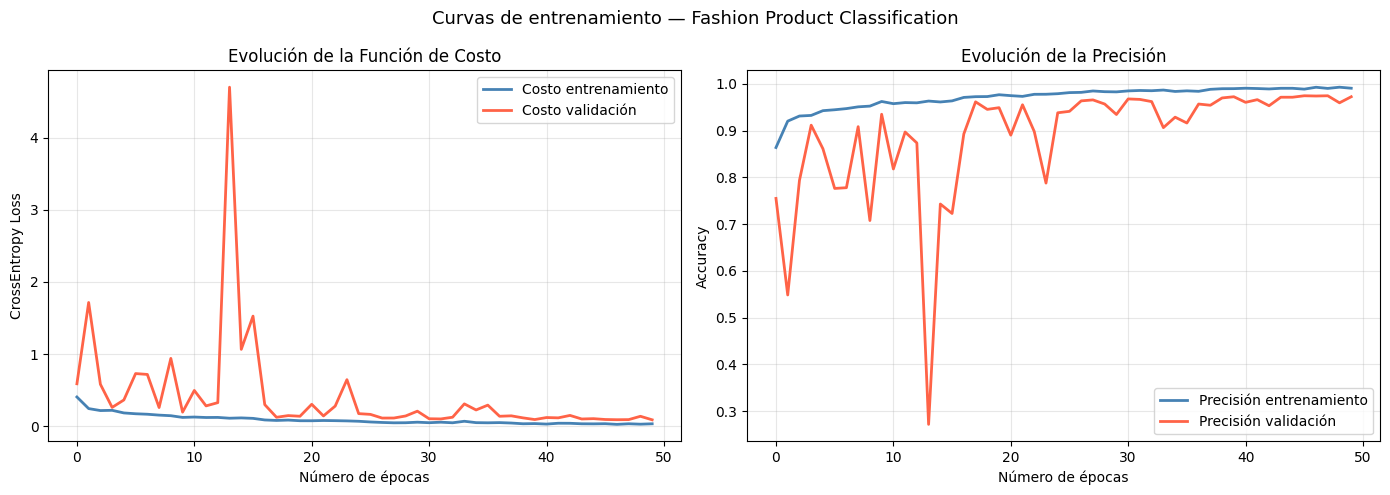

In [25]:
# ─── Gráficas de costo y precisión (requeridas en la consigna) ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfica de Costo (equivalente a pyplot.plot(cost_history) del lab anterior)
axes[0].plot(historico_costo_train, label='Costo entrenamiento', color='steelblue', lw=2)
axes[0].plot(historico_costo_test,  label='Costo validación',    color='tomato',    lw=2)
axes[0].set_xlabel('Número de épocas')
axes[0].set_ylabel('CrossEntropy Loss')
axes[0].set_title('Evolución de la Función de Costo')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Gráfica de Precisión ──────────────────────────────────────────────────────
axes[1].plot(historico_acc_train, label='Precisión entrenamiento', color='steelblue', lw=2)
axes[1].plot(historico_acc_test,  label='Precisión validación',    color='tomato',    lw=2)
axes[1].set_xlabel('Número de épocas')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Evolución de la Precisión')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de entrenamiento — Fashion Product Classification', fontsize=13)
plt.tight_layout()
plt.show()

In [26]:
# ─── Precisión final en entrenamiento y validación ───────────────────────────
print(f"Precisión en entrenamiento: {historico_acc_train[-1]*100:.2f}%")
print(f"Precisión en validación:    {historico_acc_test[-1]*100:.2f}%")
print(f"Mejor precisión alcanzada:  {mejor_acc*100:.2f}%")

Precisión en entrenamiento: 99.06%
Precisión en validación:    97.24%
Mejor precisión alcanzada:  97.45%


In [27]:
# ─── Reporte completo de clasificación ───────────────────────────────────────
# Muestra precisión, recall y F1-score para CADA categoría de moda
# Precisión: de las que dijo que eran Apparel, ¿cuántas eran realmente Apparel?
# Recall:    de todas las Apparel reales, ¿cuántas detectó correctamente?
# F1-score:  promedio armónico entre precisión y recall

modelo.eval()
todas_pred, todas_labels = [], []

with torch.no_grad():
    for img_batch, label_batch in dataloader_test:
        logits = modelo(img_batch)
        todas_pred.extend(torch.argmax(logits, dim=1).cpu().numpy())
        todas_labels.extend(label_batch.cpu().numpy())

print("Reporte de clasificación por categoría:")
print(classification_report(
    todas_labels,
    todas_pred,
    target_names=le.classes_
))

Reporte de clasificación por categoría:
               precision    recall  f1-score   support

  Accessories       0.94      0.97      0.96       481
      Apparel       0.99      0.95      0.97       480
     Footwear       0.99      1.00      0.99       481
Personal Care       0.98      0.98      0.98       481

     accuracy                           0.97      1923
    macro avg       0.97      0.97      0.97      1923
 weighted avg       0.97      0.97      0.97      1923



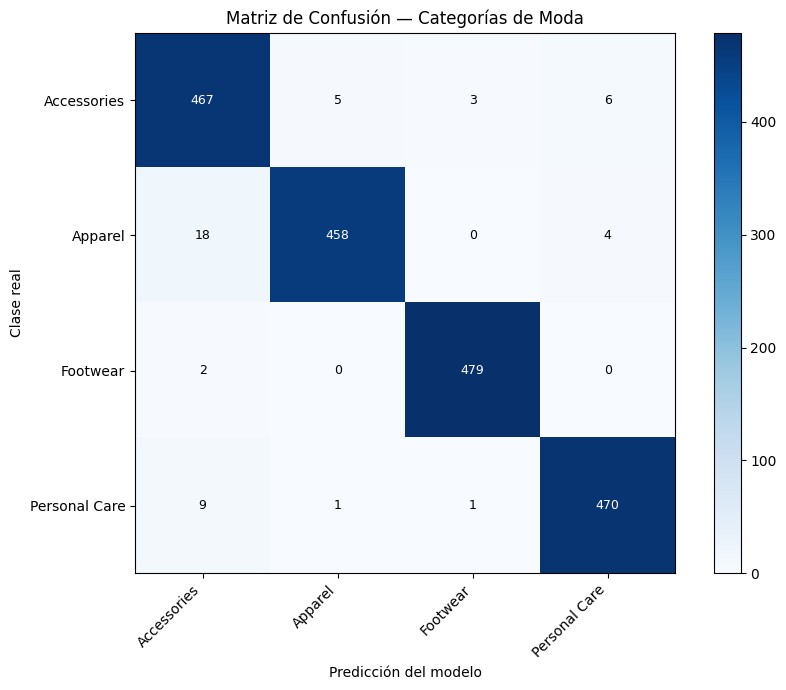

In [28]:
# ─── Matriz de confusión ──────────────────────────────────────────────────────
# Muestra para cada clase real cuántas veces fue predicha como cada otra clase
# La diagonal principal = predicciones correctas
# Fuera de la diagonal = errores (confusiones entre clases)

cm = confusion_matrix(todas_labels, todas_pred)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

n_clases_plot = len(le.classes_)
ax.set_xticks(range(n_clases_plot))
ax.set_yticks(range(n_clases_plot))
ax.set_xticklabels(le.classes_, rotation=45, ha='right')
ax.set_yticklabels(le.classes_)
ax.set_xlabel('Predicción del modelo')
ax.set_ylabel('Clase real')
ax.set_title('Matriz de Confusión — Categorías de Moda')

# Escribir los números dentro de cada celda
for i in range(n_clases_plot):
    for j in range(n_clases_plot):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=9)

plt.tight_layout()
plt.show()

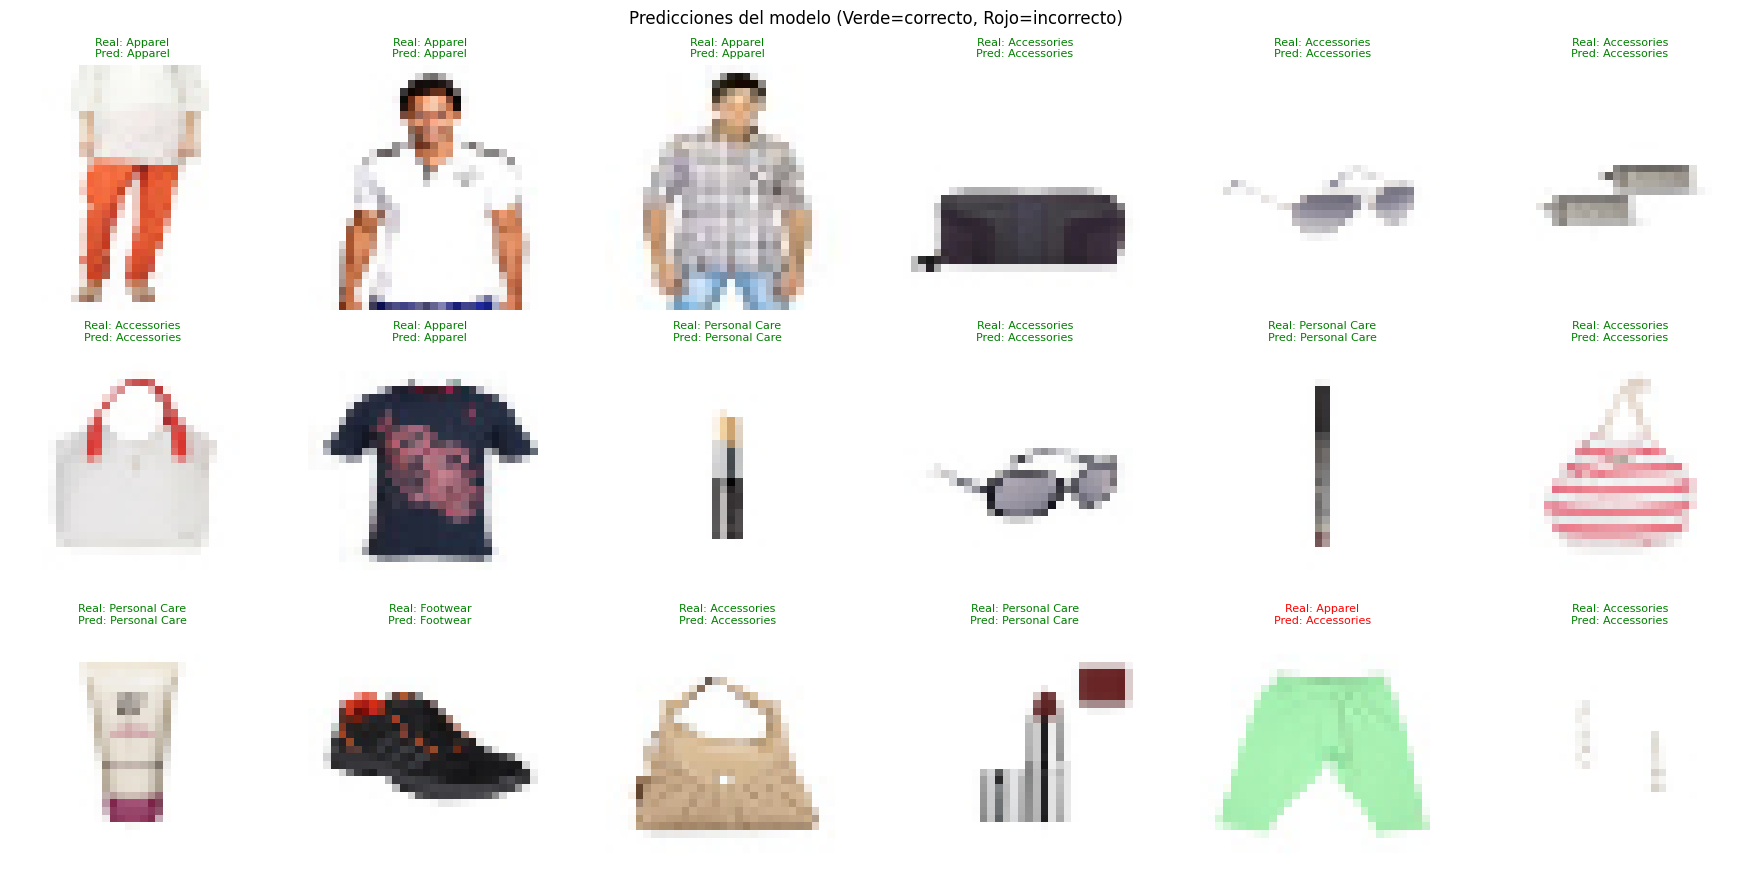

In [29]:
# ─── Visualización de predicciones correctas e incorrectas ───────────────────
# Mostramos imágenes del test con su etiqueta real y la predicha por el modelo
# Verde = predicción correcta | Rojo = predicción incorrecta

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.flatten()

indices_test = np.random.choice(len(X_test), 18, replace=False)

modelo.eval()
with torch.no_grad():
    for i, idx in enumerate(indices_test):
        img_tensor = torch.tensor(X_test[idx], dtype=torch.float32).unsqueeze(0).to(device)
        logit = modelo(img_tensor)
        pred_clase = torch.argmax(logit, dim=1).item()

        img_display = X_test[idx].reshape(32, 32, 3)
        axes[i].imshow(img_display)

        real_nombre = le.classes_[y_test[idx]]
        pred_nombre = le.classes_[pred_clase]
        correcto = (pred_clase == y_test[idx])

        color = 'green' if correcto else 'red'
        axes[i].set_title(f"Real: {real_nombre}\nPred: {pred_nombre}",
                          color=color, fontsize=8)
        axes[i].axis('off')

plt.suptitle('Predicciones del modelo (Verde=correcto, Rojo=incorrecto)', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Guardar y Cargar el Modelo
Aplicamos lo del cuadernillo 04: guardamos el `state_dict` y verificamos que el modelo cargado predice igual.

In [30]:
# ─── Guardar el state_dict (método recomendado del cuadernillo 04) ───────────
PATH_FINAL = './multiclase_modelo_final.pt'
torch.save(modelo.state_dict(), PATH_FINAL)
print(f"Modelo guardado en: {PATH_FINAL}")

# ─── Cargar el modelo ─────────────────────────────────────────────────────────
# Instanciamos la misma arquitectura y cargamos los pesos guardados
modelo_cargado = RedMulticlase(n_entradas=N_ENTRADAS, n_clases=NUM_CLASES).to(device)
modelo_cargado.load_state_dict(torch.load(PATH_FINAL, weights_only=True))
modelo_cargado.eval()
print("Modelo cargado correctamente ✔")

# Verificamos que las predicciones son idénticas
img_verificacion = dataset_test[0][0].unsqueeze(0)
with torch.no_grad():
    pred_orig   = torch.argmax(modelo(img_verificacion)).item()
    pred_cargado = torch.argmax(modelo_cargado(img_verificacion)).item()

print(f"\nPredicción modelo original: {le.classes_[pred_orig]}")
print(f"Predicción modelo cargado:  {le.classes_[pred_cargado]}")
print("Ambos coinciden ✔" if pred_orig == pred_cargado else "¡Diferencia detectada!")

Modelo guardado en: ./multiclase_modelo_final.pt
Modelo cargado correctamente ✔

Predicción modelo original: Personal Care
Predicción modelo cargado:  Personal Care
Ambos coinciden ✔


## 11. Predicción sobre una Imagen Nueva
Cargamos una imagen nueva (puede ser .jpg o .webp), la preprocesamos  
y el modelo predice a qué categoría de moda pertenece.

Archivo 'img_prueba.jpg' no encontrado.
Cambiá img_path por la ruta correcta de tu imagen.

→ Mostrando predicción sobre imagen del conjunto de test:
  Categoría real:    Personal Care
  Categoría predicha: Personal Care
  Confianza:         100.0%


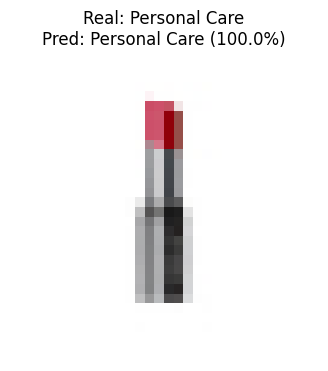

In [31]:
# ─── Predicción sobre una imagen nueva ───────────────────────────────────────
# Cambiá img_path por la ruta de la imagen que querés clasificar
# Puede ser cualquier imagen de ropa, calzado o accesorio

img_path = 'img_prueba.jpg'   # ← cambiá por tu imagen

if os.path.exists(img_path):
    # ── Cargar la imagen ──────────────────────────────────────────────────────
    # Usamos PIL para compatibilidad con .webp y otros formatos
    img_pil = Image.open(img_path).convert('RGB')

    # ── Preprocesamiento: MISMO proceso que hicimos con el dataset ────────────
    # 1. Redimensionar a 32x32
    img_pil = img_pil.resize((32, 32))
    # 2. Convertir a numpy
    img_np = np.array(img_pil, dtype=np.float32)
    # 3. Normalizar (0-255 → 0.0-1.0)
    img_np = img_np / 255.0
    # 4. Aplanar a vector de 3072 valores
    img_np = img_np.flatten()

    # ── Convertir a tensor y agregar dimensión de batch ───────────────────────
    img_tensor = torch.tensor(img_np, dtype=torch.float32).unsqueeze(0).to(device)

    # ── Predicción ────────────────────────────────────────────────────────────
    modelo_cargado.eval()
    with torch.no_grad():
        logits = modelo_cargado(img_tensor)
        # Softmax convierte los scores a probabilidades (suma = 1)
        probabilidades = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        clase_pred = np.argmax(probabilidades)

    # ── Mostrar resultado ─────────────────────────────────────────────────────
    print("=" * 50)
    print("     PREDICCIÓN DE CATEGORÍA DE MODA")
    print("=" * 50)
    print(f"  Categoría predicha: {le.classes_[clase_pred]}")
    print(f"  Confianza:          {probabilidades[clase_pred]*100:.1f}%")
    print()
    print("  Probabilidades por categoría:")
    for i, (clase, prob) in enumerate(zip(le.classes_, probabilidades)):
        barra = '█' * int(prob * 30)
        print(f"    {clase:<20} {prob*100:5.1f}% {barra}")
    print("=" * 50)

    # Mostrar la imagen
    plt.figure(figsize=(4, 4))
    plt.imshow(img_pil)
    plt.title(f"Predicción: {le.classes_[clase_pred]}\nConfianza: {probabilidades[clase_pred]*100:.1f}%",
              fontsize=12)
    plt.axis('off')
    plt.show()

else:
    print(f"Archivo '{img_path}' no encontrado.")
    print("Cambiá img_path por la ruta correcta de tu imagen.")
    print()
    # Hacemos una predicción de demostración con una imagen del test
    print("→ Mostrando predicción sobre imagen del conjunto de test:")
    idx_demo = np.random.randint(0, len(X_test))
    img_demo = torch.tensor(X_test[idx_demo], dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        logits_demo = modelo_cargado(img_demo)
        probs_demo  = torch.softmax(logits_demo, dim=1).squeeze().cpu().numpy()
        clase_demo  = np.argmax(probs_demo)

    print(f"  Categoría real:    {le.classes_[y_test[idx_demo]]}")
    print(f"  Categoría predicha: {le.classes_[clase_demo]}")
    print(f"  Confianza:         {probs_demo[clase_demo]*100:.1f}%")

    plt.figure(figsize=(4, 4))
    plt.imshow(X_test[idx_demo].reshape(32, 32, 3))
    plt.title(f"Real: {le.classes_[y_test[idx_demo]]}\nPred: {le.classes_[clase_demo]} ({probs_demo[clase_demo]*100:.1f}%)")
    plt.axis('off')
    plt.show()

## Resumen

Aplicamos las herramientas de los cuadernillos 02, 03 y 04 al modelo de  
clasificación multiclase del laboratorio anterior (One-vs-All con imágenes):

| Concepto lab anterior | Equivalente en PyTorch | Cuadernillo |
|---|---|---|
| Entrenar K clasificadores One-vs-All | Una sola `RedMulticlase` con K salidas | 02 |
| `sigmoid()` por cada clase | `CrossEntropyLoss` (Softmax implícito) | 02 |
| `gradiente descendente` manual | `torch.optim.Adam` | 02 |
| Iterar imágenes manualmente | `FashionDataset` + `DataLoader` batches de 64 | 03 |
| Sin guardado del modelo | `torch.save` + checkpoint del mejor accuracy | 04 |
| `argmax(sigmoid(X @ all_theta.T))` | `torch.argmax(logits, dim=1)` | 02 |

**Ventajas respecto al laboratorio anterior:**
- Un solo modelo aprende todas las clases simultáneamente (vs K modelos separados)
- BatchNorm estabiliza el entrenamiento con imágenes
- Dropout previene que el modelo memorice las imágenes de entrenamiento
- El checkpoint guarda automáticamente el modelo con mejor accuracy en validación
